In [161]:
from pathlib import Path
import csv
import numpy as np
import pandas as pd
from scipy.io import mmread
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

In [162]:
DATA_DIR = Path("activin_dataset/.")
OUT = Path("CSV")
OUT.mkdir(exist_ok=True)

N_REPEATS = 30
TEST_SIZE = 0.30
N_NEIGHBORS = 5
RANDOM_SEED = 1
NORMALIZE_COUNTS = True

In [163]:
#convert the file name in the name of the parameters 
#def clean_label(path):
#    name = path.stem.replace("hierarchy_gene_list_", "")
#    return name.replace("n_is_", "n=").replace("_pct_", ", pct=").replace("0pnt", "0.")


#take the unique gene 
def read_gene_set(path):
    genes = set()
    with path.open(newline="") as f:
        for row in csv.reader(f):
            for cell in row:
                genes.update(g.strip() for g in str(cell).split(";") if g.strip())
    return genes

In [164]:
#gene_files = sorted(DATA_DIR.glob("real_activin_hierarchy_gene_list*.csv"))
#if not gene_files:
#    raise FileNotFoundError("No hierarchy_gene_list_*.csv files found.")

#read the important file 
genes = pd.read_csv(DATA_DIR / "features.tsv.gz", sep="\t", header=None, names=["gene_id", "gene_symbol", "gene_exp"])
barcodes = pd.read_csv(DATA_DIR / "barcodes.tsv.gz", sep="\t", header=None, names=["barcode"])
labels_df = pd.read_csv(DATA_DIR / "d1_metadata_SCP.tsv", sep="\t", header=0)
labels_df = labels_df.drop(labels_df[labels_df['NAME'] == 'TYPE'].index)
labels_df = (labels_df[['NAME', 'cell_type__ontology_label']].rename(columns={'cell_type__ontology_label': 'cell_type', 'NAME': 'barcode'}))
labels_df.head()


,barcode,cell_type
1,AAACGAACAGCTGTGC-1,macrophage
2,AAACGAATCAAGGAGC-1,macrophage
3,AAACGAATCGGCGATC-1,macrophage
4,AAACGCTCAGCGTACC-1,neutrophil
5,AAACGCTCAGCTGTAT-1,macrophage


In [165]:
genes.head()

,gene_id,gene_symbol,gene_exp
0,ENSMUSG00000051951,Xkr4,Gene Expression
1,ENSMUSG00000089699,Gm1992,Gene Expression
2,ENSMUSG00000102343,Gm37381,Gene Expression
3,ENSMUSG00000025900,Rp1,Gene Expression
4,ENSMUSG00000025902,Sox17,Gene Expression


In [166]:
barcodes.head()

,barcode
0,AAACCCAAGAAACACT-1
1,AAACCCAAGAAACCAT-1
2,AAACCCAAGAAACCCA-1
3,AAACCCAAGAAACCCG-1
4,AAACCCAAGAAACCTG-1


In [167]:
#load matrix and align cells with Seurat labels
X = mmread(DATA_DIR / "matrix.mtx.gz").tocsr().T
barcode_to_pos = {bc: i for i, bc in enumerate(barcodes["barcode"])}
kept = labels_df[labels_df["barcode"].isin(barcode_to_pos)].copy()
X = X[[barcode_to_pos[bc] for bc in kept["barcode"]], :]
y = kept["cell_type"].to_numpy()


In [168]:
X

<Compressed Sparse Column sparse matrix of dtype 'int64'
	with 4396885 stored elements and shape (1781, 31053)>

In [169]:
y

array(['macrophage', 'macrophage', 'macrophage', ..., 'neutrophil',
       'neutrophil', 'neutrophil'], shape=(1781,), dtype=object)

In [170]:
#normalize counts because scRNA-seq preprocessing
if NORMALIZE_COUNTS:
    lib_size = np.asarray(X.sum(axis=1)).ravel()
    lib_size[lib_size == 0] = 1.0
    X = X.multiply((10000.0 / lib_size)[:, None]).tocsr()
    X.data = np.log1p(X.data)

In [171]:
#link gene symbols to matrix columns
symbol_to_idx = {}
for i, symbol in enumerate(genes["gene_id"].astype(str)):
    symbol_to_idx.setdefault(symbol, i)

In [172]:
symbol_to_idx

{'ENSMUSG00000051951': 0,
 'ENSMUSG00000089699': 1,
 'ENSMUSG00000102343': 2,
 'ENSMUSG00000025900': 3,
 'ENSMUSG00000025902': 4,
 'ENSMUSG00000104328': 5,
 'ENSMUSG00000033845': 6,
 'ENSMUSG00000025903': 7,
 'ENSMUSG00000104217': 8,
 'ENSMUSG00000033813': 9,
 'ENSMUSG00000002459': 10,
 'ENSMUSG00000085623': 11,
 'ENSMUSG00000033793': 12,
 'ENSMUSG00000025905': 13,
 'ENSMUSG00000033774': 14,
 'ENSMUSG00000025907': 15,
 'ENSMUSG00000090031': 16,
 'ENSMUSG00000087247': 17,
 'ENSMUSG00000033740': 18,
 'ENSMUSG00000051285': 19,
 'ENSMUSG00000097797': 20,
 'ENSMUSG00000103067': 21,
 'ENSMUSG00000025909': 22,
 'ENSMUSG00000061024': 23,
 'ENSMUSG00000025911': 24,
 'ENSMUSG00000067879': 25,
 'ENSMUSG00000099827': 26,
 'ENSMUSG00000025912': 27,
 'ENSMUSG00000045210': 28,
 'ENSMUSG00000097893': 29,
 'ENSMUSG00000025915': 30,
 'ENSMUSG00000046101': 31,
 'ENSMUSG00000098234': 32,
 'ENSMUSG00000099032': 33,
 'ENSMUSG00000025916': 34,
 'ENSMUSG00000087199': 35,
 'ENSMUSG00000025917': 36,
 'ENSMUSG00

In [173]:
#evaluation with the parameters settings
path = Path("real_activin_hierarchy_gene_list.csv")
setting = 'No settings used'
marker_genes = read_gene_set(path)

marker_genes

{'ENSMUSG00000000817',
 'ENSMUSG00000000903',
 'ENSMUSG00000002504',
 'ENSMUSG00000003379',
 'ENSMUSG00000003534',
 'ENSMUSG00000004056',
 'ENSMUSG00000004612',
 'ENSMUSG00000004655',
 'ENSMUSG00000006386',
 'ENSMUSG00000006731',
 'ENSMUSG00000008540',
 'ENSMUSG00000009633',
 'ENSMUSG00000015947',
 'ENSMUSG00000019987',
 'ENSMUSG00000020573',
 'ENSMUSG00000021322',
 'ENSMUSG00000021986',
 'ENSMUSG00000022548',
 'ENSMUSG00000022816',
 'ENSMUSG00000023132',
 'ENSMUSG00000024516',
 'ENSMUSG00000024910',
 'ENSMUSG00000025150',
 'ENSMUSG00000025163',
 'ENSMUSG00000026009',
 'ENSMUSG00000026170',
 'ENSMUSG00000026536',
 'ENSMUSG00000027315',
 'ENSMUSG00000027624',
 'ENSMUSG00000028156',
 'ENSMUSG00000028268',
 'ENSMUSG00000028270',
 'ENSMUSG00000028763',
 'ENSMUSG00000028927',
 'ENSMUSG00000029309',
 'ENSMUSG00000029373',
 'ENSMUSG00000030165',
 'ENSMUSG00000030257',
 'ENSMUSG00000030724',
 'ENSMUSG00000031494',
 'ENSMUSG00000031613',
 'ENSMUSG00000031715',
 'ENSMUSG00000032053',
 'ENSMUSG00

In [174]:
print(f"Marker genes in file: {len(marker_genes)}")
print(f"Genes matched in matrix: {len(gene_idx)}")
print(f"Sample gene_idx values: {gene_idx[:5]}")
print(f"Non-zero elements in X_sub: {X_sub.nnz}")
print(f"Total possible: {X_sub.shape[0] * X_sub.shape[1]}")
print(f"Sparsity: {1 - X_sub.nnz / (X_sub.shape[0] * X_sub.shape[1]):.4%}")
print(f"X shape after transpose: {X.shape}")  # should be (n_cells, n_genes) = (1781, 31053)
print(f"barcodes length: {len(barcodes)}")     # should match X rows
print(f"genes length: {len(genes)}") 

Marker genes in file: 100
Genes matched in matrix: 100
Sample gene_idx values: [1289, 15147, 27845, 12452, 28245]
Non-zero elements in X_sub: 14
Total possible: 178100
Sparsity: 99.9921%
X shape after transpose: (1781, 31053)
barcodes length: 6794880
genes length: 31053


In [175]:
#repeated stratified train/test evaluation
splitter = StratifiedShuffleSplit(n_splits=N_REPEATS, test_size=TEST_SIZE, random_state=RANDOM_SEED)
rows = []

gene_idx = [symbol_to_idx[g] for g in sorted(marker_genes) if g in symbol_to_idx]

if not gene_idx:
    raise ValueError(f"No marker genes from {setting} were found in genes.tsv")

X_sub = X[:, gene_idx]


for repeat, (train_idx, test_idx) in enumerate(splitter.split(X_sub, y), start=1):
    model = KNeighborsClassifier(n_neighbors=N_NEIGHBORS)
    model.fit(X_sub[train_idx], y[train_idx])
    pred = model.predict(X_sub[test_idx])

    rows.append({
        "parameter_setting": setting,
        "repeat": repeat,
        "n_marker_genes_in_file": len(marker_genes),
        "n_marker_genes_found_in_matrix": len(gene_idx),
        "accuracy": accuracy_score(y[test_idx], pred),
        "macro_f1": f1_score(y[test_idx], pred, average="macro"),
    })

In [176]:
X_sub

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 35686 stored elements and shape (1781, 100)>

In [177]:
#summarise KNN
results = pd.DataFrame(rows)
order = sorted(results["parameter_setting"].unique())

summary = results.groupby("parameter_setting").agg(
    mean_accuracy=("accuracy", "mean"),
    sd_accuracy=("accuracy", "std"),
    mean_macro_f1=("macro_f1", "mean"),
    sd_macro_f1=("macro_f1", "std"),
    n_marker_genes_in_file=("n_marker_genes_in_file", "first"),
    n_marker_genes_found_in_matrix=("n_marker_genes_found_in_matrix", "first"),
    n_repeats=("repeat", "count"),
).reindex(order)

results.to_csv(OUT / "fig3_knn_accuracy_results.csv", index=False)
summary.to_csv(OUT / "fig3_knn_accuracy_summary.csv")

print("Saved raw KNN CSV files in", OUT)
print(summary)
summary

Saved raw KNN CSV files in CSV
                   mean_accuracy  sd_accuracy  mean_macro_f1  sd_macro_f1  \
parameter_setting                                                           
No settings used         0.96405     0.005481       0.928256     0.012252   

                   n_marker_genes_in_file  n_marker_genes_found_in_matrix  \
parameter_setting                                                           
No settings used                      100                             100   

                   n_repeats  
parameter_setting             
No settings used          30  


,mean_accuracy,sd_accuracy,mean_macro_f1,sd_macro_f1,n_marker_genes_in_file,n_marker_genes_found_in_matrix,n_repeats
parameter_setting,,,,,,,
No settings used,0.96405,0.005481,0.928256,0.012252,100,100,30


In [179]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from umap import UMAP 

In [180]:
# Reuse the gene_idx and X_sub from your existing notebook
X_dense = X_sub.toarray()          # (n_cells, n_marker_genes)

# PCA-style reduction to 50 dims before UMAP / t-SNE
n_components = min(50, X_dense.shape[1] - 1)
svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_SEED)
X_reduced = svd.fit_transform(X_dense)

In [181]:
reducer = UMAP(
    n_neighbors=15,
    min_dist=0.3,
    n_components=2,
    random_state=RANDOM_SEED,
)
X_umap = reducer.fit_transform(X_reduced)

embed_df = pd.DataFrame({
    "UMAP1": X_umap[:, 0],
    "UMAP2": X_umap[:, 1],
    "cell_type": y,           # ground-truth labels from your notebook
})

c:\Users\jefgr\Desktop\bio_code\Hierarchical-Maker-Genes-Selection-for-scRNA-seq-Data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


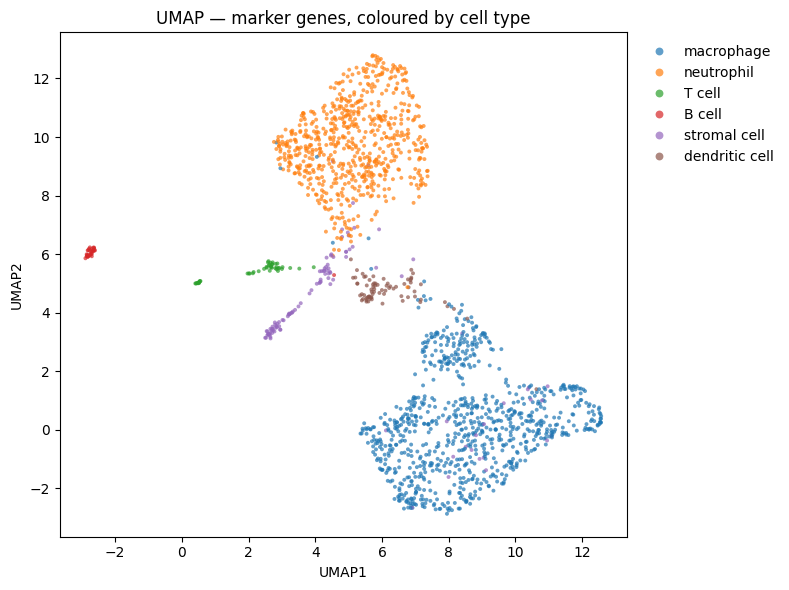

In [182]:
fig, ax = plt.subplots(figsize=(8, 6))

palette = sns.color_palette("tab10", n_colors=embed_df["cell_type"].nunique())
sns.scatterplot(
    data=embed_df,
    x="UMAP1", y="UMAP2",
    hue="cell_type",
    palette=palette,
    s=8, alpha=0.7, linewidths=0,
    ax=ax,
)
ax.set_title("UMAP — marker genes, coloured by cell type")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False, markerscale=2)
plt.tight_layout()
plt.savefig("umap_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

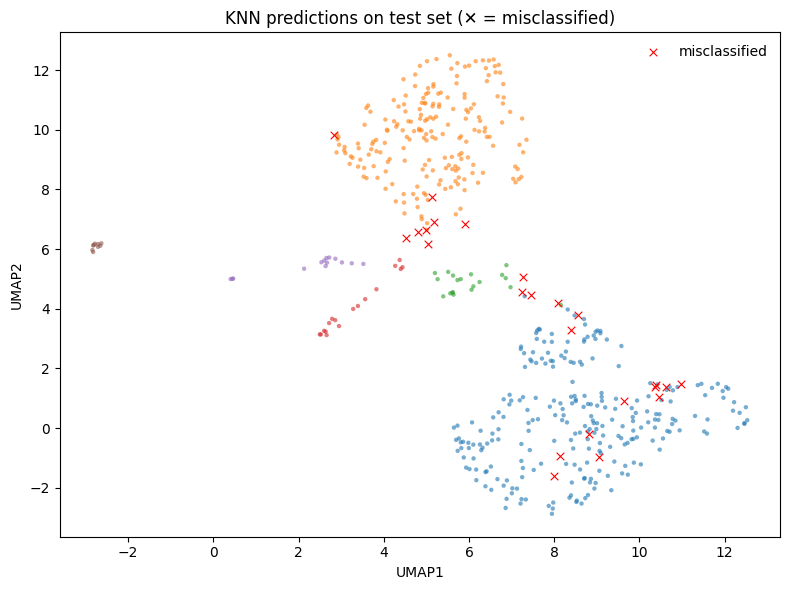

In [183]:
# Run one train/test split to get predicted labels
from sklearn.neighbors import KNeighborsClassifier

train_idx, test_idx = next(splitter.split(X_sub, y))
knn = KNeighborsClassifier(n_neighbors=N_NEIGHBORS)
knn.fit(X_sub[train_idx], y[train_idx])
preds = knn.predict(X_sub[test_idx])

# Mark correct vs wrong on the UMAP
test_df = embed_df.iloc[test_idx].copy()
test_df["correct"] = (preds == y[test_idx])

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=test_df[test_df["correct"]], x="UMAP1", y="UMAP2",
               hue="cell_type", palette=palette, s=10, alpha=0.6,
               linewidths=0, ax=ax, legend=False)
sns.scatterplot(data=test_df[~test_df["correct"]], x="UMAP1", y="UMAP2",
               color="red", marker="x", s=30, linewidths=0.8,
               ax=ax, label="misclassified")
ax.set_title("KNN predictions on test set (✕ = misclassified)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()